**GEN AI ASSIGNMENT 08 — MNIST Autoencoder & VAE**

**Step 1: Import Libraries**

In [43]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, Model
from tensorflow.keras.datasets import mnist

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


**Step 2: GPU Detection**

In [44]:
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("GPU Available")
    print(gpus)
else:
    print("Running on CPU")

GPU Available
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


**Step 3: Load MNIST Dataset**

In [45]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training Shape:", x_train.shape)
print("Testing Shape :", x_test.shape)

Training Shape: (60000, 28, 28)
Testing Shape : (10000, 28, 28)


**Step 4: Display Images Before Training**

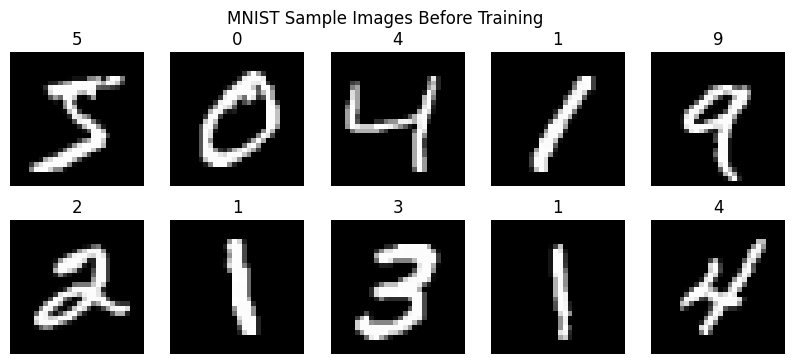

In [46]:
plt.figure(figsize=(10,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')

plt.suptitle("MNIST Sample Images Before Training")
plt.show()

**Step 5: Preprocessing**

In [47]:
x_train = x_train.astype("float32")/255.
x_test = x_test.astype("float32")/255.

x_train = x_train.reshape((-1,784))
x_test = x_test.reshape((-1,784))

# **PART A — SIMPLE AUTOENCODER**

**Step 6: Build Autoencoder (Sigmoid)**

In [48]:
latent_dim = 2

# Encoder
encoder_inputs = layers.Input(shape=(784,))
x = layers.Dense(128, activation='relu')(encoder_inputs)
latent = layers.Dense(latent_dim, name="latent")(x)

encoder = Model(encoder_inputs, latent, name="Encoder")

# Decoder
latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(128, activation='relu')(latent_inputs)
decoder_outputs = layers.Dense(784, activation='sigmoid')(x)

decoder = Model(latent_inputs, decoder_outputs, name="Decoder")

# Autoencoder
autoencoder = Model(encoder_inputs,
                    decoder(encoder(encoder_inputs)),
                    name="Autoencoder")

autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

autoencoder.summary()

Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder (Functional)            │ (None, 2)              │       100,738 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder (Functional)            │ (None, 784)            │       101,520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 202,258 (790.07 KB)

 Trainable params: 202,258 (790.07 KB)

 Non-trainable params: 0 (0.00 B)

**Step 7: Train Autoencoder (15 Epochs)**

In [49]:
history = autoencoder.fit(
    x_train,
    x_train,
    epochs=20,
    batch_size=256,
    validation_data=(x_test, x_test),
    verbose=1
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.2793 - val_loss: 0.2351
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2294 - val_loss: 0.2217
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2185 - val_loss: 0.2144
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2121 - val_loss: 0.2091
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2070 - val_loss: 0.2047
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2035 - val_loss: 0.2022
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2009 - val_loss: 0.2000
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1987 - val_loss: 0.1980
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1967 - val_loss: 0.1961
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1951 - val_loss: 0.1949
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1937 - val_loss: 0.1936
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

**Step 8: Loss Visualization**

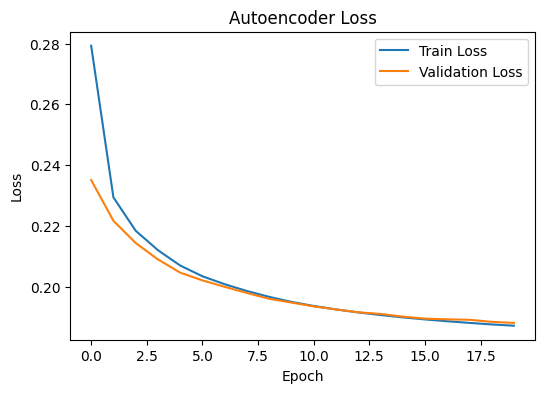

In [50]:
plt.figure(figsize=(6,4))

plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.title("Autoencoder Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

**Step 9: Latent Space Visualization**

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


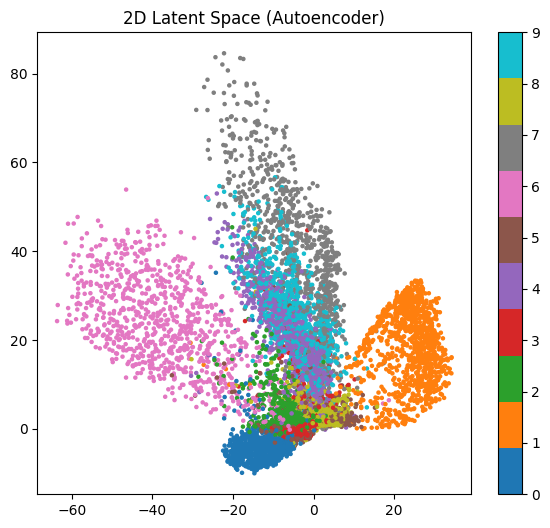

In [51]:
latent_points = encoder.predict(x_test)

plt.figure(figsize=(7,6))

plt.scatter(
    latent_points[:,0],
    latent_points[:,1],
    c=y_test,
    cmap="tab10",
    s=5
)

plt.colorbar()
plt.title("2D Latent Space (Autoencoder)")
plt.show()

**Step 10: Reconstruct Images**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step


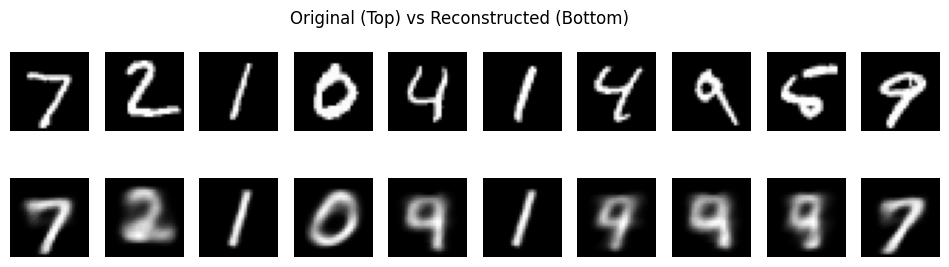

In [52]:
reconstructed = autoencoder.predict(x_test[:10])

plt.figure(figsize=(12,3))

for i in range(10):

    plt.subplot(2,10,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.axis("off")

    plt.subplot(2,10,i+11)
    plt.imshow(reconstructed[i].reshape(28,28), cmap='gray')
    plt.axis("off")

plt.suptitle("Original (Top) vs Reconstructed (Bottom)")
plt.show()

# **PART B — VARIATIONAL AUTOENCODER (VAE)**

**Step 11: Sampling Layer**

In [53]:
class Sampling(layers.Layer):

    def call(self, inputs):

        z_mean, z_log_var = inputs

        epsilon = tf.random.normal(shape=tf.shape(z_mean))

        return z_mean + tf.exp(0.5*z_log_var)*epsilon

**Step 12: Build Encoder**

In [54]:
latent_dim = 2

encoder_inputs = layers.Input(shape=(784,))

x = layers.Dense(256, activation="relu")(encoder_inputs)

z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

z = Sampling()([z_mean, z_log_var])

encoder = Model(
    encoder_inputs,
    [z_mean, z_log_var, z],
    name="VAE_Encoder"
)

encoder.summary()

Model: "VAE_Encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 256)       │    200,960 │ input_layer_10[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 2)         │        514 │ dense_19[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 2)         │        514 │ dense_19[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_2          │ (None, 2)         │          0 │ dense_20[0][0],   │
│ (Sampling)          │                   │            │ dense_21[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 201,988 (789.02 KB)

 Trainable params: 201,988 (789.02 KB)

 Non-trainable params: 0 (0.00 B)

Step 13: Build Decoder

In [55]:
latent_inputs = layers.Input(shape=(latent_dim,))

x = layers.Dense(256, activation="relu")(latent_inputs)

decoder_outputs = layers.Dense(784, activation="sigmoid")(x)

decoder = Model(
    latent_inputs,
    decoder_outputs,
    name="VAE_Decoder"
)

decoder.summary()

Model: "VAE_Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 202,256 (790.06 KB)

 Trainable params: 202,256 (790.06 KB)

 Non-trainable params: 0 (0.00 B)

**Step 14: Build VAE with KL Divergence**

In [56]:
import tensorflow as tf
from tensorflow.keras import Model

class VAE(Model):
    def __init__(self, encoder, decoder):
        super(VAE, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data, training=True)
            reconstruction = self.decoder(z, training=True)

            # Reconstruction loss
            reconstruction_loss = tf.reduce_mean(
                tf.keras.losses.binary_crossentropy(data, reconstruction)
            ) * 784

            # KL Divergence loss
            kl_loss = tf.reduce_mean(
                -0.5 * tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        return {
            "loss": total_loss,
            "reconstruction_loss": reconstruction_loss,
            "kl_loss": kl_loss,
        }

In [57]:
vae = VAE(encoder, decoder)
vae.compile(optimizer=tf.keras.optimizers.Adam())

**Step 15: Train VAE (15 Epochs)**

In [58]:
loss_history = []
recon_history = []
kl_history = []

for epoch in range(20):

    print(f"\nEpoch {epoch+1}/20")

    h = vae.fit(
        x_train,
        epochs=1,
        batch_size=256,
        verbose=1
    )

    loss_history.append(h.history["loss"][0])
    recon_history.append(h.history["reconstruction_loss"][0])
    kl_history.append(h.history["kl_loss"][0])


Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - kl_loss: 5.8138 - loss: 186.8959 - reconstruction_loss: 181.0821 

Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 4.6863 - loss: 182.7192 - reconstruction_loss: 178.0329

Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - kl_loss: 4.3844 - loss: 174.0126 - reconstruction_loss: 169.6282

Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 4.6799 - loss: 169.9902 - reconstruction_loss: 165.3103

Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 4.9643 - loss: 170.9542 - reconstruction_loss: 165.9899

Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 5.1160 - loss: 162.4307 - reconstruction_loss: 157.3148

Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 4.9549 - loss: 168.6694 - reconstruction_loss: 163.7146

Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 5.3714 - loss: 159.3769 - reconstruction_loss: 154.0056

Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━

**Step 16: VAE Training Loss Visualization**

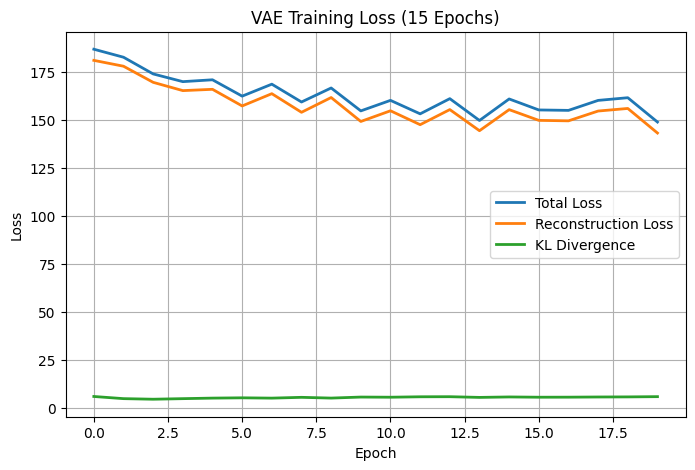

In [59]:
plt.figure(figsize=(8,5))

plt.plot(loss_history, label="Total Loss", linewidth=2)
plt.plot(recon_history, label="Reconstruction Loss", linewidth=2)
plt.plot(kl_history, label="KL Divergence", linewidth=2)

plt.title("VAE Training Loss (15 Epochs)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

**Step 17: Visualize the 2D Latent Space**

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


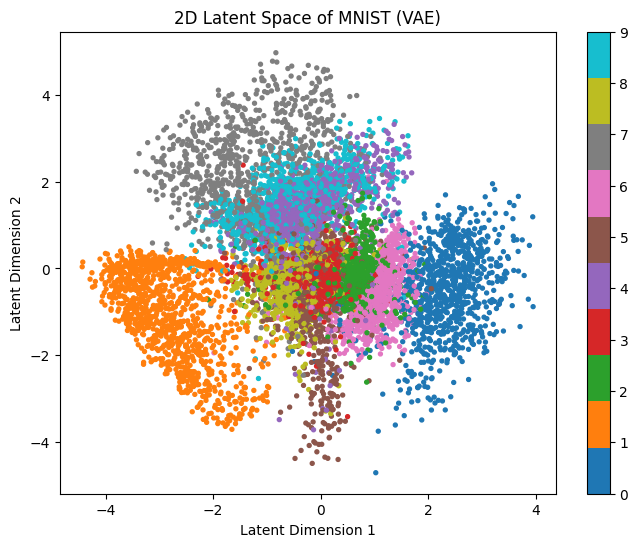

In [60]:
# Encode the test images
z_mean, z_log_var, z = encoder.predict(x_test, batch_size=256)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    z_mean[:,0],
    z_mean[:,1],
    c=y_test,
    cmap="tab10",
    s=8
)

plt.colorbar(scatter)
plt.title("2D Latent Space of MNIST (VAE)")
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")

plt.show()

**Step 18: Original vs Reconstructed Images**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step


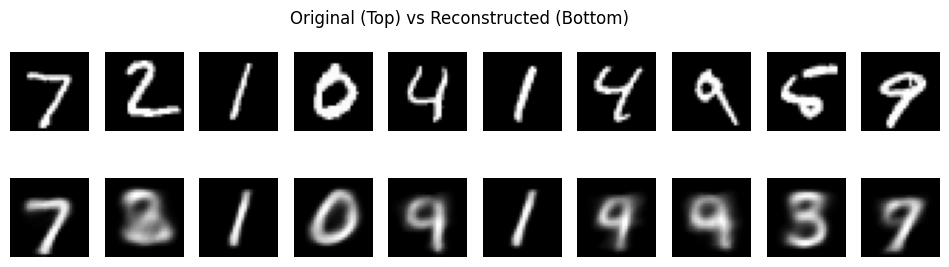

In [61]:
# Encode and decode first 10 test images
z_mean, z_log_var, z = encoder.predict(x_test[:10])
reconstructed = decoder.predict(z)

plt.figure(figsize=(12,3))

for i in range(10):

    # Original
    plt.subplot(2,10,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap="gray")
    plt.axis("off")

    # Reconstructed
    plt.subplot(2,10,i+11)
    plt.imshow(reconstructed[i].reshape(28,28), cmap="gray")
    plt.axis("off")

plt.suptitle("Original (Top) vs Reconstructed (Bottom)")
plt.show()

**Generate digits across latent space**

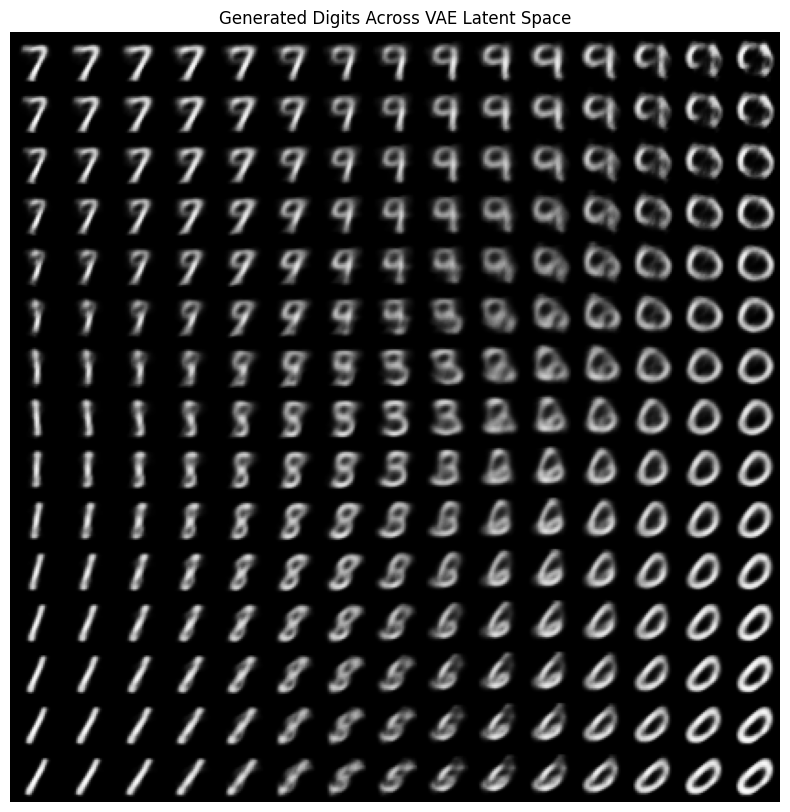

In [62]:
n = 15
digit_size = 28
scale = 2.5

figure = np.zeros((digit_size * n, digit_size * n))

grid_x = np.linspace(-scale, scale, n)
grid_y = np.linspace(-scale, scale, n)[::-1]

for i, yi in enumerate(grid_y):
    for j, xi in enumerate(grid_x):

        z_sample = np.array([[xi, yi]], dtype=np.float32)

        x_decoded = decoder.predict(z_sample, verbose=0)
        digit = x_decoded[0].reshape(28, 28)

        figure[
            i * digit_size:(i + 1) * digit_size,
            j * digit_size:(j + 1) * digit_size
        ] = digit

plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap="gray")
plt.title("Generated Digits Across VAE Latent Space")
plt.axis("off")
plt.show()

1. Do similar digits form clusters?

Yes. Similar handwritten digits such as 3, 5, and 8 tend to appear close together because they share visual characteristics. **bold text**

2. Are the clusters clearly separated?

Most clusters are distinguishable, although some overlap occurs between visually similar digits like 4 and 9 or 3 and 5. **bold text**

3. How do generated digits change across latent space?

As the latent coordinates move gradually from −3 to +3, the generated images continuously transform from one digit style to another.

 4. Is the transition smooth?

Yes. The VAE learns a continuous latent representation, producing smooth and realistic transitions between generated handwritten digits.